In [ ]:
# Setup & Config


import os
import re
import random
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# (Optional HF streaming later)
try:
    from datasets import load_dataset  # we'll use this in a later cell
except Exception:
    load_dataset = None

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Categories & Sampling ----
# Choose 3 categories for balanced sentiment dataset
CATEGORIES = ["All_Beauty", "Electronics", "Books"]
SAMPLES_PER_CATEGORY = 50_000          # rows per category
MIN_TEXT_LEN = 10                      # drop ultra-short reviews
MAX_TOKENS = 256                       # truncate long texts later (token-aware in a later cell)

# ---- Columns we care about for sentiment/review analysis ----
COLS_TO_KEEP = [
    "rating", "text", "title", "asin", "user_id", "timestamp", "verified_purchase", "helpful_vote"
]

# ---- Local project paths ----
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Output file (per-category files will be named later)
OUTPUT_DIR = PROCESSED_DIR / "amazon_sentiment_subsets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Hugging Face settings (used in a later cell) ----
HF_REPO = "McAuley-Lab/Amazon-Reviews-2023"
USE_HF_STREAMING = True        # stream instead of full download
TRUST_REMOTE_CODE = True       # required by this dataset

def hf_config_name(category: str) -> str:
    """Map human category to HF config (e.g., 'All_Beauty' -> 'raw_review_All_Beauty')."""
    return f"raw_review_{category}"

warnings.filterwarnings("ignore")

print("=== Sentiment/Review Prep — Config ===")
print(f"Seed: {SEED}")
print(f"Categories: {CATEGORIES}")
print(f"Samples per category: {SAMPLES_PER_CATEGORY}")
print(f"Columns kept: {COLS_TO_KEEP}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"HF streaming: {USE_HF_STREAMING}, trust_remote_code: {TRUST_REMOTE_CODE}")


=== Sentiment/Review Prep — Config ===
Seed: 42
Categories: ['All_Beauty', 'Electronics', 'Books']
Samples per category: 50000
Columns kept: ['rating', 'text', 'title', 'asin', 'user_id', 'timestamp', 'verified_purchase', 'helpful_vote']
Output dir: /home/niranjanrao07/cod-multiagent-ecommerce/notebooks/data/processed/amazon_sentiment_subsets
HF streaming: True, trust_remote_code: True


In [4]:
#Direct JSONL Stream

import json
import pandas as pd
import requests

def stream_jsonl_sample(category: str, n_samples: int = 50_000, sample_bytes: int = 40_000_000):
    """
    Reads a limited number of reviews from Hugging Face JSONL file for a given category.
    Downloads only the first portion of the file to reduce bandwidth.
    """
    jsonl_url = f"https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/{category}.jsonl"
    print(f"Streaming category: {category}")
    print(f"URL: {jsonl_url}")

    # Request partial content to limit data transfer
    headers = {"Range": f"bytes=0-{sample_bytes}"}
    response = requests.get(jsonl_url, headers=headers, timeout=60)
    response.raise_for_status()

    # Parse line by line
    lines = response.text.splitlines()
    records = []
    for line in lines:
        try:
            obj = json.loads(line)
            if "text" in obj and obj["text"] and len(obj["text"]) >= MIN_TEXT_LEN:
                records.append({k: obj.get(k, None) for k in COLS_TO_KEEP})
        except Exception:
            continue
        if len(records) >= n_samples:
            break

    df = pd.DataFrame(records)
    print(f"Retrieved {len(df)} valid reviews from {category}")

    out_path = OUTPUT_DIR / f"{category.lower()}_{len(df)}.parquet"
    df.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}\n")

    return df


# Stream and save selected categories
category_dfs = {}
for cat in CATEGORIES:
    df_cat = stream_jsonl_sample(cat, n_samples=SAMPLES_PER_CATEGORY)
    category_dfs[cat] = df_cat

print("All categories streamed and saved locally.")


Streaming category: All_Beauty
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl
Retrieved 50000 valid reviews from All_Beauty
Saved: /home/niranjanrao07/cod-multiagent-ecommerce/notebooks/data/processed/amazon_sentiment_subsets/all_beauty_50000.parquet

Streaming category: Electronics
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl
Retrieved 50000 valid reviews from Electronics
Saved: /home/niranjanrao07/cod-multiagent-ecommerce/notebooks/data/processed/amazon_sentiment_subsets/electronics_50000.parquet

Streaming category: Books
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Books.jsonl
Retrieved 35969 valid reviews from Books
Saved: /home/niranjanrao07/cod-multiagent-ecommerce/notebooks/data/processed/amazon_sentiment_subsets/books_35969.parquet

All categories streamed and saved loca

In [5]:
# Data Cleaning & Normalization
import re

def clean_text(text):
    """Basic text normalization for reviews."""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)              # remove URLs
    text = re.sub(r"[^a-z0-9\s.,!?]", "", text)      # keep only basic characters
    text = re.sub(r"\s+", " ", text).strip()         # collapse whitespace
    return text


# Load all sampled parquet files
dfs = []
for cat in CATEGORIES:
    file_path = OUTPUT_DIR / f"{cat.lower()}_50000.parquet"
    if not file_path.exists():
        # handle Books with fewer samples
        file_path = list(OUTPUT_DIR.glob(f"{cat.lower()}_*.parquet"))[0]
    df = pd.read_parquet(file_path)
    df["category"] = cat
    dfs.append(df)

# Combine and clean
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.drop_duplicates(subset=["user_id", "text"], inplace=True)
combined_df.dropna(subset=["text"], inplace=True)

# Normalize text
combined_df["text"] = combined_df["text"].apply(clean_text)
combined_df["title"] = combined_df["title"].fillna("").apply(clean_text)

print("Combined shape after cleaning:", combined_df.shape)

# Save cleaned combined dataset
cleaned_path = OUTPUT_DIR / "amazon_sentiment_cleaned.parquet"
combined_df.to_parquet(cleaned_path, index=False)
print("Saved cleaned dataset:", cleaned_path)


Combined shape after cleaning: (133730, 9)
Saved cleaned dataset: /home/niranjanrao07/cod-multiagent-ecommerce/notebooks/data/processed/amazon_sentiment_subsets/amazon_sentiment_cleaned.parquet


Total reviews: 133730
sentiment
positive    105003
negative     17203
neutral      11524
Name: count, dtype: int64

Average rating per category:
 category
All_Beauty     4.05
Books          4.35
Electronics    4.24
Name: rating, dtype: float64


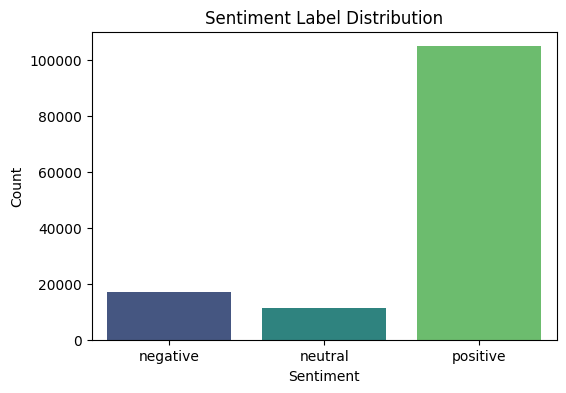

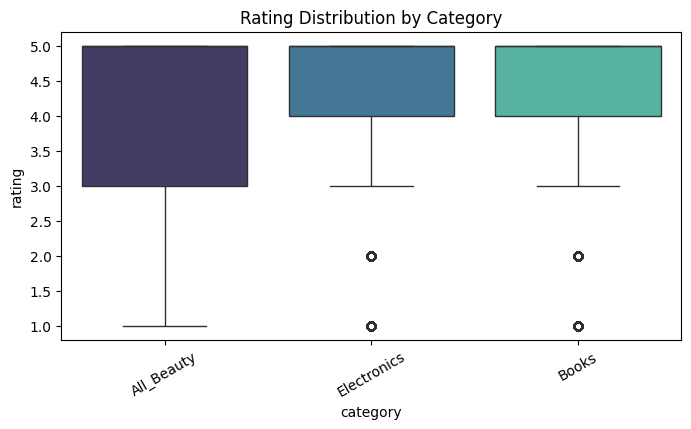


Sample positive review:
 my laptop doesnt have an ethernet port, so i thought id try this device. it works very well. i connect to ethernet no problem. i would recommend it.

Sample negative review:
 nailtiqes charges 7.50 for these!!!!!


In [6]:
#Label Generation & EDA


import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
cleaned_path = OUTPUT_DIR / "amazon_sentiment_cleaned.parquet"
df = pd.read_parquet(cleaned_path)

# Map rating → sentiment label
def map_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(map_sentiment)

# Quick summary
print("Total reviews:", len(df))
print(df["sentiment"].value_counts())
print("\nAverage rating per category:\n", df.groupby("category")["rating"].mean().round(2))

# Visualize label distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment", order=["negative", "neutral", "positive"], palette="viridis")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Category-level distribution
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="category", y="rating", palette="mako")
plt.title("Rating Distribution by Category")
plt.xticks(rotation=30)
plt.show()

# Display sample reviews for inspection
print("\nSample positive review:\n", df[df["sentiment"]=="positive"].sample(1, random_state=42)["text"].values[0])
print("\nSample negative review:\n", df[df["sentiment"]=="negative"].sample(1, random_state=42)["text"].values[0])
